In [49]:
# mlp for regression
from numpy import sqrt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [50]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

In [51]:
import tensorflow as tf

In [52]:
from matplotlib import pyplot as plt
import random


In [53]:
def balance_classes(df, column_name="Age"):
    """
    Balance the classes in a dataframe by downsampling the majority classes
    
    :param df: The dataframe to balance
    :param column_name: The name of the column to balance by

    :return: The balanced dataframe
    """

    df['group'] = pd.cut(df[column_name], bins=[-np.inf, 35, 65, np.inf], labels=[1, 2, 3], right=False)
    min_group_size = df['group'].value_counts().min()  # Calculate the size of the smallest group
    sample_size = min_group_size + random.randint(-50, 50)  # Add some randomness to the sample size
    balanced_df = pd.DataFrame()
    for value in [1, 2, 3]:
        subset = df[df['group'] == value]
        if len(subset) <= sample_size:
            balanced_df = pd.concat([balanced_df, subset])
        else:
            balanced_subset = subset.sample(sample_size)
            balanced_df = pd.concat([balanced_df, balanced_subset])
    balanced_df = balanced_df.drop(columns=['group'])
    return balanced_df


In [54]:
# load the dataset
df = pd.read_csv('Data/trainign_dataset_51270_microarray_unadjusted.csv')


/tmp/ipykernel_15824/3176704610.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/trainign_dataset_51270_microarray_unadjusted.csv')


In [55]:
df.iloc[1:5, 1:5]


,U48705,M87338,X51757,X69699
1,1635.300049,390.899994,252.199997,795.000000
2,1006.799988,383.200012,198.199997,924.000000
3,1215.800049,496.200012,160.600006,500.899994
4,823.599976,561.500000,305.500000,1214.099976


In [100]:
df.shape

(1173, 51282)

In [56]:
np.mean(df["Age"])

44.12171355498722

(array([ 56.,  95., 110.,  71.,  59.,  51.,  44.,  71.,  93., 173., 119.,
         32.,  31.,  43.,  50.,  23.,  34.,  12.,   4.,   2.]),
 array([18. , 21.4, 24.8, 28.2, 31.6, 35. , 38.4, 41.8, 45.2, 48.6, 52. ,
        55.4, 58.8, 62.2, 65.6, 69. , 72.4, 75.8, 79.2, 82.6, 86. ]),
 <BarContainer object of 20 artists>)

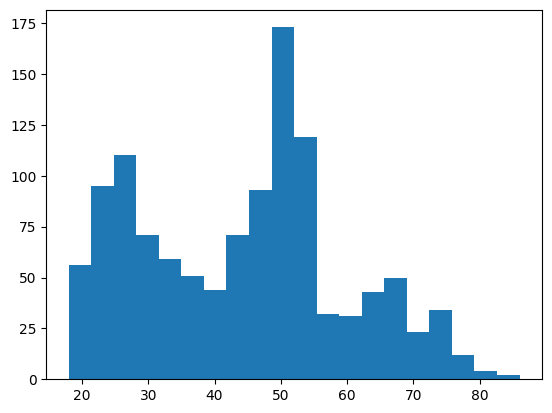

In [57]:
plt.hist(df["Age"], bins=20)

In [58]:
sampled_df = balance_classes(df)

In [59]:
sampled_df[sampled_df["Age"]<35].shape

(129, 51281)

In [60]:
sampled_df

,Sample,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,...,AI571298,AA149545,C18318,AI219073,AI205180,AI363375,Experiment,Sex,Age,Status
946,GSM4717024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,GSE155959,Male,33.00,training status: PRE
1155,GSM244528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,GSE9676,Male,27.10,NaN
860,GSM4716938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,GSE155959,Male,33.00,training status: POST
291,GSM23747,372.80,82.600,109.400,1268.800,11.300,152.500,85.500,19.500,19.200,...,0.000,0.00,0.000,0.000,0.000,0.000,GSE1428,Male,18.00,NaN
1125,GSM576661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,GSE23527,Male,28.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137,GSM10387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,GSE674_1,Female,66.00,NaN
726,GSM230406,87.65,57.472,17.901,51.801,16.025,16.908,22.553,70.881,111.038,...,180.386,59.46,12.715,18.258,46.077,46.018,GSE9103,Male,65.48,Trained
665,GSM10368,5174.00,4883.000,28191.000,12102.000,14979.000,4564.000,21547.000,11482.000,2052.000,...,0.000,0.00,0.000,0.000,0.000,0.000,GSE674_2,Female,68.00,NaN
1157,GSM244552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,GSE9676,Female,65.10,NaN


In [61]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [62]:
# Zscale normalization  
scaler = StandardScaler()
normalize_sampled_df = sampled_df.drop(['Age', 'Experiment', 'Sex', "Status"], axis=1).set_index('Sample', inplace=False)
normalize_sampled_df = scaler.fit_transform(normalize_sampled_df)



(array([14., 33., 40., 21., 21.,  9.,  8., 17., 20., 27., 32.,  9.,  3.,
        17., 45., 23., 30., 12.,  4.,  2.]),
 array([18. , 21.4, 24.8, 28.2, 31.6, 35. , 38.4, 41.8, 45.2, 48.6, 52. ,
        55.4, 58.8, 62.2, 65.6, 69. , 72.4, 75.8, 79.2, 82.6, 86. ]),
 <BarContainer object of 20 artists>)

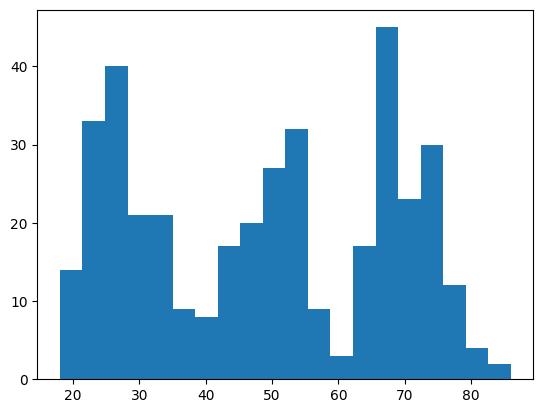

In [63]:
plt.hist(sampled_df["Age"], bins=20)

In [64]:

# split into input and output columns
X = normalize_sampled_df
y = sampled_df['Age'].values

# remove rows with all missing values
mask = np.isnan(X).all(axis=1)
X= X[~mask]
y= y[~mask]



In [65]:
type(y)

numpy.ndarray

In [66]:
len(X)

230

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
#X_train = np.asarray(X_train).astype(np.float32)
#y_train = np.asarray(y_train).astype(np.float32)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(154, 51276) (76, 51276) (154,) (76,)


In [68]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso

In [69]:
lasso = Lasso(alpha=0.1)  # Adjust the alpha parameter
selector = SelectFromModel(lasso)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.397e+02, tolerance: 3.995e+00
  model = cd_fast.enet_coordinate_descent(


In [70]:
selected_feature_indices = selector.get_support()

# Get the names of the selected features
features = list(selected_feature_indices)
#features.append(True)

In [71]:
len(features)

51276

In [72]:
len(normalize_sampled_df[0])

51276

In [73]:
all_genes =  sampled_df.drop(['Age', 'Experiment', 'Sex', "Status"], axis=1).set_index('Sample', inplace=False).columns
selected_genes = all_genes[features]
selected_genes[:10]

Index(['NM_080871', 'NM_138994', 'NM_052852', 'BC038230', 'AB062477',
       'AL834267', 'AK098734', 'BC040662', 'BC036850', 'BM664532'],
      dtype='object')

In [74]:
filtered_df = sampled_df[selected_genes]

In [75]:
filtered_df.columns

Index(['NM_080871', 'NM_138994', 'NM_052852', 'BC038230', 'AB062477',
       'AL834267', 'AK098734', 'BC040662', 'BC036850', 'BM664532',
       ...
       'AW151637', 'BE243270', 'BE568225', 'AL542291', 'AW070323', 'AW207574',
       'AA121271', 'AI142390', 'BF197429', 'J03553'],
      dtype='object', length=117)

In [76]:
X = filtered_df

# remove rows with all missing values
mask = np.isnan(X).all(axis=1)
X= X[~mask]


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
#X_train = np.asarray(X_train).astype(np.float32)
#y_train = np.asarray(y_train).astype(np.float32)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(154, 117) (76, 117) (154,) (76,)


In [78]:
y_train[0:10]

array([53.36, 22.  , 34.2 , 68.4 , 22.38, 68.  , 21.96, 73.5 , 64.  ,
       58.02])

In [79]:
len(X)

230

In [80]:
X_train

,NM_080871,NM_138994,NM_052852,BC038230,AB062477,AL834267,AK098734,BC040662,BC036850,BM664532,...,AW151637,BE243270,BE568225,AL542291,AW070323,AW207574,AA121271,AI142390,BF197429,J03553
15,193.100006,222.399994,253.000000,24.299999,15.700000,12.700000,277.600006,149.100006,331.899994,22.000000,...,19.700001,8.800000,19.000000,22.500000,98.599998,15.200000,27.200001,35.799999,10.400000,286.299988
571,26.904500,0.001881,535.310000,15.963400,141.614000,76.138300,127.378000,111.626000,49.620300,106.558000,...,23.643400,612.454000,5.018200,8.034300,2.074130,0.002458,2.795050,0.019739,4.116210,50.469900
678,801.715990,5.741560,20.913770,6.976695,23.343751,88.480835,73.853326,10.497760,36.445713,97.020920,...,38.674793,169.066559,127.725703,49.265759,10.269206,13.643119,44.708334,104.747406,22.423037,147.561172
756,56.972700,3.823210,491.306000,6.842340,280.308000,76.149800,7.947880,4.556820,151.230000,655.311000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
326,7.247494,2.512139,2.927238,2.444373,2.979500,4.142605,4.464927,2.473661,2.593246,5.634388,...,3.835035,3.857452,3.066090,2.918457,2.893696,2.840124,3.161183,4.549241,3.004468,5.188889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,6.812554,2.020782,4.004063,2.402564,3.538590,4.987383,5.880141,2.562764,2.598106,6.929015,...,4.352824,8.519659,3.749686,3.403661,2.752037,2.376606,3.275470,4.630057,2.823909,5.330072
765,43.416000,4.484500,444.198000,5.993700,335.513000,80.122000,7.957880,4.503590,43.057100,308.954000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,250.399994,3.400000,164.199997,11.200000,77.500000,106.500000,337.100006,7.600000,112.300003,433.299988,...,96.400002,575.299988,33.000000,7.300000,8.400000,6.100000,21.000000,14.000000,12.800000,54.900002
528,46.110600,7.240710,556.009000,2.642890,119.323000,78.735000,93.915200,128.207000,17.947700,128.828000,...,29.385900,588.794000,6.069410,7.217700,0.003326,0.001610,6.254990,6.855960,4.646920,50.320900


In [81]:
from tensorflow.keras.layers import Layer


In [82]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

In [83]:
# determine the number of input features
n_features = X_train.shape[1]
# define model
loss = tf.keras.losses.Poisson()
# normalization + loss funtion + cross valitation
model = Sequential()
in_shape = X_train.shape[1:]
model.add(Dense(64, activation='relu', kernel_initializer='random_normal', input_shape=(n_features,)))
#model.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_uniform', input_shape=in_shape))
model.add(Dense(8, activation='relu', kernel_initializer='he_normal'))
#model.add(Dense(2, activation='sigmoid', kernel_initializer='he_normal'))
model.add(Dense(1))
# compile the model
# change loss funtion
from tensorflow.keras.optimizers import SGD
sgd = SGD(learning_rate=0.001, momentum=0.8)
model.compile(optimizer='adam', loss='binary_crossentropy')
#model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#model.compile(optimizer='adam', loss=loss)

# fit the model
fitted_one = model.fit(X_train, y_train, epochs=1500, batch_size=15, verbose=0)


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
#model.add(Layer.

In [85]:


## add cross valitation

In [86]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,245 (94.71 KB)

 Trainable params: 8,081 (31.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,164 (63.14 KB)

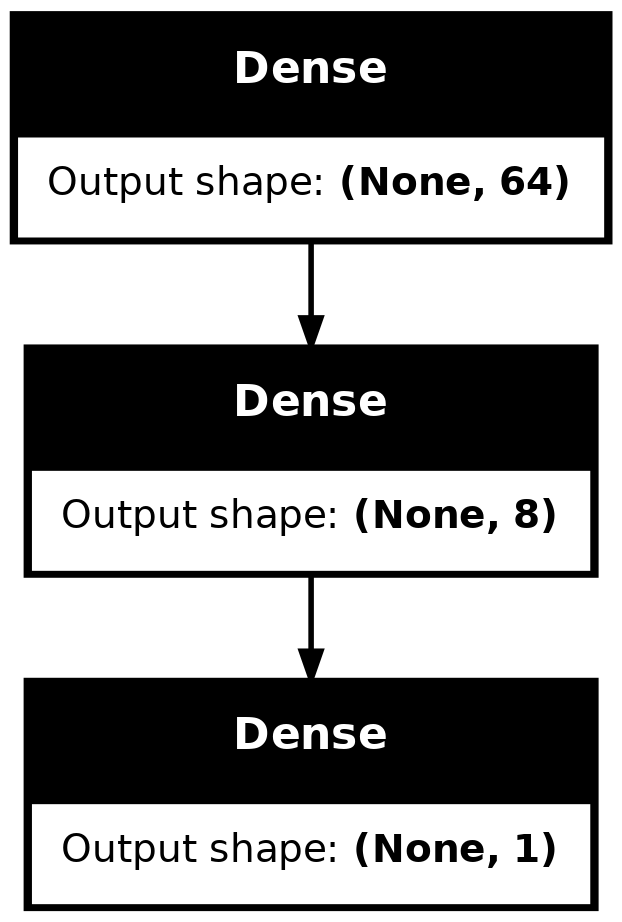

In [87]:
plot_model(model, 'model.png', show_shapes=True)

In [88]:
X_train.shape

(154, 117)

In [89]:
error = model.evaluate(X, y, verbose=0)
#print('MSE: %.3f, RMSE: %.3f' % (error, sqrt(error)))
error

-774.7533569335938

In [90]:
# evaluate the model
error = model.evaluate(X_test, y_test, verbose=0)
#print('MSE: %.3f, RMSE: %.3f' % (error, sqrt(error)))
error
# make a prediction


-759.749267578125

In [91]:
X_new = X_test
y_new= y_test
# Make predictions using the trained model
predictions = model.predict(X_new)

# If your target variable is a single numeric value (regression), you can use predictions directly
# For example, if predictions is a 2D array, you can flatten it to a 1D array
predictions_flat = np.ravel(predictions)



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [92]:
X_new

,NM_080871,NM_138994,NM_052852,BC038230,AB062477,AL834267,AK098734,BC040662,BC036850,BM664532,...,AW151637,BE243270,BE568225,AL542291,AW070323,AW207574,AA121271,AI142390,BF197429,J03553
742,164.747000,5.382000,6.868000,3.541000,19.527000,20.444000,12.916000,4.840000,4.925000,22.160000,...,28.722000,30.228000,38.776000,9.134000,12.392000,7.010000,24.482000,27.172000,5.060000,32.791000
769,42.526500,3.495780,240.164000,5.687420,251.217000,79.900700,6.951020,4.502420,189.813000,441.870000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
434,7.135097,2.056932,4.194084,2.242117,2.999462,4.312411,6.057843,2.511777,2.939139,6.795406,...,4.311849,8.743793,3.819579,3.436099,2.570563,2.431776,3.619837,4.706951,3.190272,5.732882
504,42.505100,2.783630,515.381000,3.561610,103.856000,89.329200,123.111000,141.138000,12.899400,264.604000,...,18.249500,718.492000,19.255800,1.938320,5.208590,0.002918,0.007523,6.046260,0.007759,47.295700
767,56.696400,4.465750,549.658000,5.986050,32.984600,34.351600,7.516830,4.534180,42.208200,117.252000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,153.800003,21.400000,166.100006,126.500000,155.300003,79.699997,433.899994,50.000000,241.300003,215.000000,...,15.900000,248.199997,35.799999,14.000000,22.200001,10.200000,33.799999,29.299999,10.100000,336.700012
467,6.810226,2.146655,4.028282,2.545694,2.987092,4.357008,5.740473,2.427688,2.684763,5.972133,...,4.285383,8.300516,3.507063,3.152925,2.687434,2.475775,3.467411,4.836079,3.094247,5.306655
100,500.899994,0.800000,147.300003,56.299999,10.200000,111.099998,436.600006,74.400002,24.600000,381.600006,...,71.699997,466.299988,71.099998,8.600000,10.000000,4.000000,9.800000,45.099998,4.200000,86.300003
125,88.599998,64.000000,127.199997,161.600006,64.900002,213.000000,204.100006,41.900002,75.699997,127.800003,...,12.400000,133.100006,13.900000,7.900000,32.500000,6.900000,30.500000,15.300000,23.600000,111.699997


In [93]:
results = pd.DataFrame(list(zip(y_new, predictions_flat)))
results=results.set_axis(["Actual", "Predicted"], axis=1)

results

,Actual,Predicted
0,25.19,103.438400
1,70.70,191.147919
2,51.00,17.613995
3,65.00,303.840424
4,22.50,176.752670
...,...,...
71,55.42,717.304077
72,60.00,16.854628
73,50.07,429.037811
74,52.46,433.649567


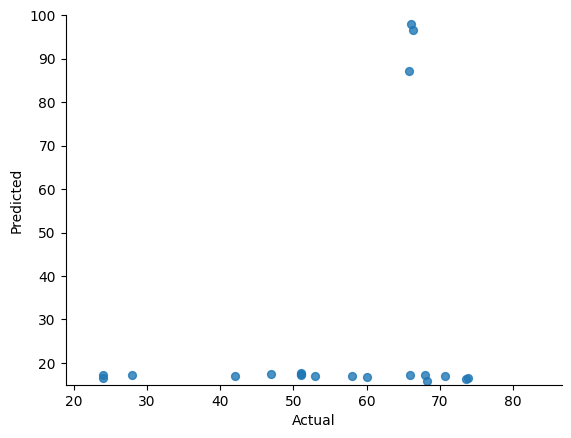

In [94]:
from matplotlib import pyplot as plt
results.plot(kind='scatter', x='Actual', y='Predicted', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)

plt.show()

In [95]:
np.max(results["Predicted"])

1007.57385

Lets try with the prune... please works :c

In [96]:
# Evaluate the original model
_, accuracy_original = model.evaluate(X_test, y_test)
print(f'Accuracy of the original model: {accuracy_original}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -740.1501 


TypeError: cannot unpack non-iterable float object

In [97]:
from matplotlib import pyplot


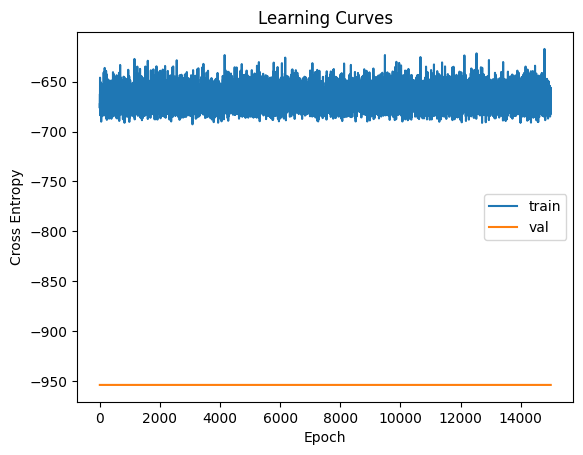

In [98]:
history = model.fit(X, y, epochs=15000, batch_size=30, verbose=0, validation_split=0.3)
# plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

KeyError: 'val_loss'

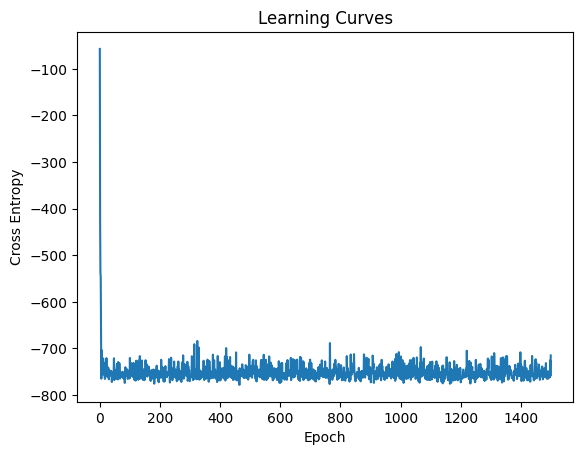

In [99]:
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(fitted_one.history['loss'], label='train')
pyplot.plot(fitted_one.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

Let's try with another model


In [109]:
new_model = Sequential()

# Add layers to the model
new_model.add(Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
new_model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))
new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
new_model.add(Dense(1))

# Compile the model
new_model.compile(optimizer='adam', loss='mse', metrics=['mae'])


new_model_history= new_model.fit(X, y, epochs=1500, batch_size=100, verbose=0, validation_split=0.1)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


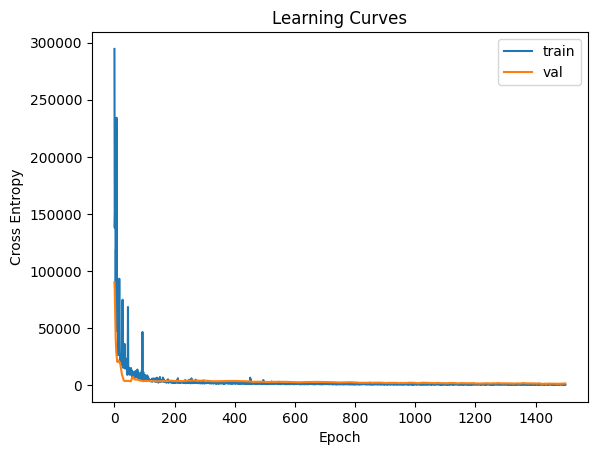

In [110]:
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(new_model_history.history['loss'], label='train')
pyplot.plot(new_model_history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/stepWARNING:tensorflow:6 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f672f9ae3b0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


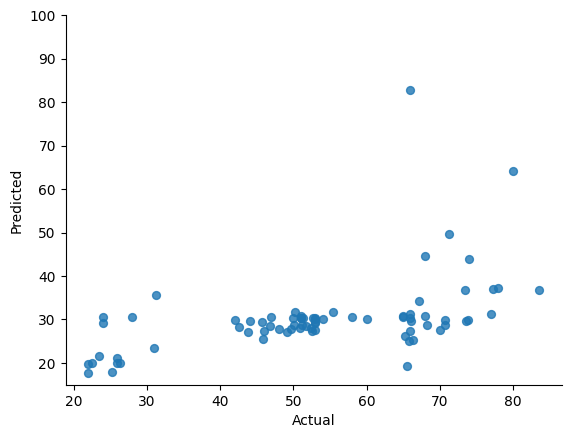

In [105]:
X_new = X_test
y_new= y_test
# Make predictions using the trained model
predictions = new_model.predict(X_new)

# If your target variable is a single numeric value (regression), you can use predictions directly
# For example, if predictions is a 2D array, you can flatten it to a 1D array
predictions_flat = np.ravel(predictions)


results = pd.DataFrame(list(zip(y_new, predictions_flat)))
results=results.set_axis(["Actual", "Predicted"], axis=1)

results.plot(kind='scatter', x='Actual', y='Predicted', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)

plt.show()

In [106]:
error = model.evaluate(X_test, y_test, verbose=0)
#print('MSE: %.3f, RMSE: %.3f' % (error, sqrt(error)))
error

-759.749267578125

In [107]:
np.max(results["Predicted"])

120.18023

In [108]:
np.min(results["Predicted"])

17.601328